In [45]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series
from prophet import Prophet

# Date handling
from datetime import datetime

# Warnings
import warnings
warnings.filterwarnings('ignore')


In [46]:
df = pd.read_csv("../data/processed/fact_sales.csv")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
392687,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,9,12
392688,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12
392689,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12
392690,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12


In [47]:
# Check dataset structure and general information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  str    
 2   Description  392692 non-null  str    
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  str    
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  str    
 8   TotalPrice   392692 non-null  float64
 9   Year         392692 non-null  int64  
 10  Month        392692 non-null  int64  
 11  Day          392692 non-null  int64  
 12  Hour         392692 non-null  int64  
dtypes: float64(3), int64(6), str(4)
memory usage: 38.9 MB


In [48]:
# Check basic statistics for numerical columns
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532
std,13087.063759,180.492832,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661
min,536365.000000,1.000000,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,561874.000000,6.000000,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000


In [49]:
# Convert InvoiceDate to datetime format (required for time series analysis)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [50]:
# Check if InvoiceDate is correctly converted to datetime
df.dtypes

InvoiceNo               int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalPrice            float64
Year                    int64
Month                   int64
Day                     int64
Hour                    int64
dtype: object

In [51]:
# Remove invalid transactions (negative or zero values)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [52]:
# Aggregate total revenue by month
monthly_sales = df.resample('ME', on='InvoiceDate')['TotalPrice'].sum().reset_index()

In [53]:
# Display first rows of aggregated data
monthly_sales.head()

,InvoiceDate,TotalPrice
0,2010-12-31,570422.730
1,2011-01-31,568101.310
2,2011-02-28,446084.920
3,2011-03-31,594081.760
4,2011-04-30,468374.331


In [54]:
# Check number of rows (number of months)
monthly_sales.shape

(13, 2)

In [55]:
# Rename columns for Prophet format
prophet_df = monthly_sales.rename(columns={
    'InvoiceDate': 'ds',
    'TotalPrice': 'y'
})

In [56]:
# Display Prophet-ready data
prophet_df

,ds,y
0,2010-12-31,570422.730
1,2011-01-31,568101.310
2,2011-02-28,446084.920
3,2011-03-31,594081.760
4,2011-04-30,468374.331
5,2011-05-31,677355.150
6,2011-06-30,660046.050
7,2011-07-31,598962.901
8,2011-08-31,644051.040
9,2011-09-30,950690.202


In [57]:
# Initialize Prophet model
model = Prophet()

# Fit model on historical data
model.fit(prophet_df)

02:24:59 - cmdstanpy - INFO - Chain [1] start processing
02:24:59 - cmdstanpy - INFO - Chain [1] done processing


In [58]:
# Create future dates (next 6 months)
future = model.make_future_dataframe(periods=6, freq='ME')

In [59]:
# Generate forecast
forecast = model.predict(future)

In [60]:
# Display forecast results
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
14,2012-02-29,9.626643e+05,756064.248571,1.179758e+06
15,2012-03-31,9.982692e+05,774510.237712,1.225377e+06
16,2012-04-30,1.032726e+06,822412.256460,1.246514e+06
17,2012-05-31,1.068330e+06,833024.380132,1.271789e+06
18,2012-06-30,1.102787e+06,882843.843083,1.310943e+06


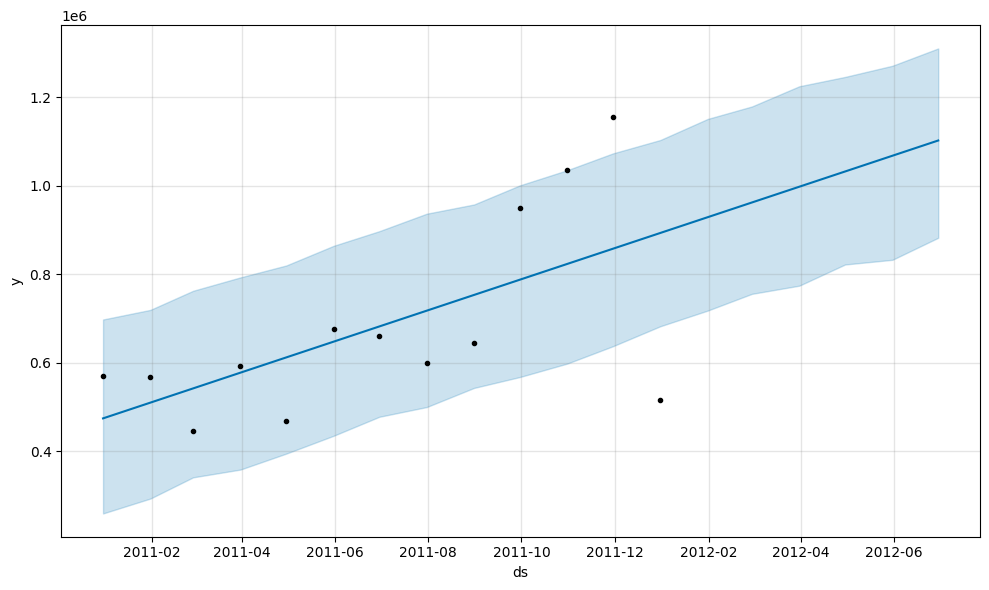

In [61]:
# Plot forecast
model.plot(forecast);

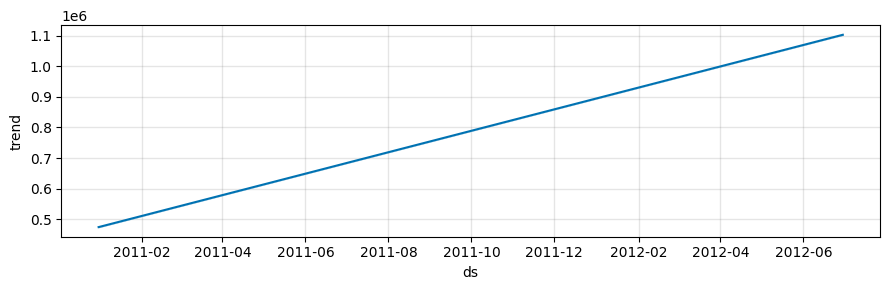

In [62]:
# Plot trend and seasonality components
model.plot_components(forecast);

In [63]:
# Split data into train and test sets (last 3 months as test)
train = prophet_df.iloc[:-3]
test = prophet_df.iloc[-3:]

In [64]:
from prophet import Prophet

# Initialize model
model = Prophet()

# Fit on training data only
model.fit(train)

02:24:59 - cmdstanpy - INFO - Chain [1] start processing
02:24:59 - cmdstanpy - INFO - Chain [1] done processing


In [65]:
# Create future dataframe for test period
future = model.make_future_dataframe(periods=3, freq='ME')

# Predict
forecast = model.predict(future)

In [66]:
# Compare predictions with actual values
forecast_test = forecast[['ds', 'yhat']].tail(3)

comparison = test.merge(forecast_test, on='ds')
comparison

,ds,y,yhat
0,2011-10-31,1035642.45,791812.410072
1,2011-11-30,1156205.61,822831.843280
2,2011-12-31,517190.44,854885.257596


In [67]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(comparison['y'], comparison['yhat'])
print("MAE:", mae)


MAE: 304966.2080811891


In [68]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))
print("RMSE:", rmse)


RMSE: 308019.9920672027


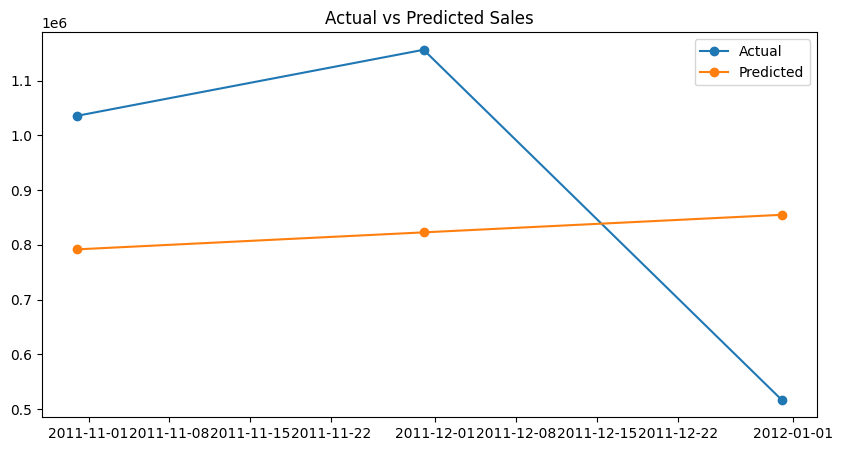

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Plot actual values
plt.plot(test['ds'], test['y'], label='Actual', marker='o')

# Plot predictions
plt.plot(comparison['ds'], comparison['yhat'], label='Predicted', marker='o')

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [70]:
# Display model evaluation metrics
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 304966.21
RMSE: 308019.99


## Conclusion - Sales Forecasting

In this section, we performed a revenue forecasting analysis based on historical sales data.

First, the `InvoiceDate` column was converted into a datetime format to enable proper time series analysis. Then, transactional data was aggregated on a monthly basis using the `TotalPrice` variable. This step transforms individual sales into a monthly time series that can be used by a forecasting model.

The model used is Prophet. This choice is appropriate because Prophet is designed for business time series data and allows easy modeling of trends over time.

The results show an overall upward trend in revenue. The model predicts continuous growth in the coming months, with revenue expected to reach around one million euros.

To evaluate the model, a time-based split was performed: the last few months were used as test data. The following metrics were obtained:

- MAE ≈ 304,966 €
- RMSE ≈ 308,020 €

These results indicate that the model captures the general trend, but the error remains relatively high. This can be explained by the limited amount of available data (only 13 months) and the significant variability in monthly revenue.

In conclusion, Prophet provides a solid baseline for understanding sales trends and forecasting future revenue. However, improving the model’s accuracy would require more historical data and potentially the inclusion of additional explanatory variables such as promotions, seasonal effects, or special business events.

In [71]:
# Save forecast results to CSV
forecast.to_csv("forecast_results.csv", index=False)

In [72]:
import pickle

# Save trained model
with open("../models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)